# Évaluation finale — SVM

Charge le pipeline final sauvegardé par `train_final.ipynb` et l'évalue sur le **jeu de test final** (split `test` HuggingFace, jamais vu pendant la CV ni la recherche d'hyperparamètres).

Métriques calculées : **accuracy**, **precision**, **recall**, **F1-score** (macro), **ROC-AUC** (one-vs-rest).

Sorties (dossier `results/svm/evaluation/`) :

- `metrics.json` — métriques + classification report,
- `confusion_matrix.png`,
- `metrics_bar.png`,
- `predictions.png`.

c:\Users\sh4rk\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\sh4rk\AppData\Local\Programs\Python\Python312\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


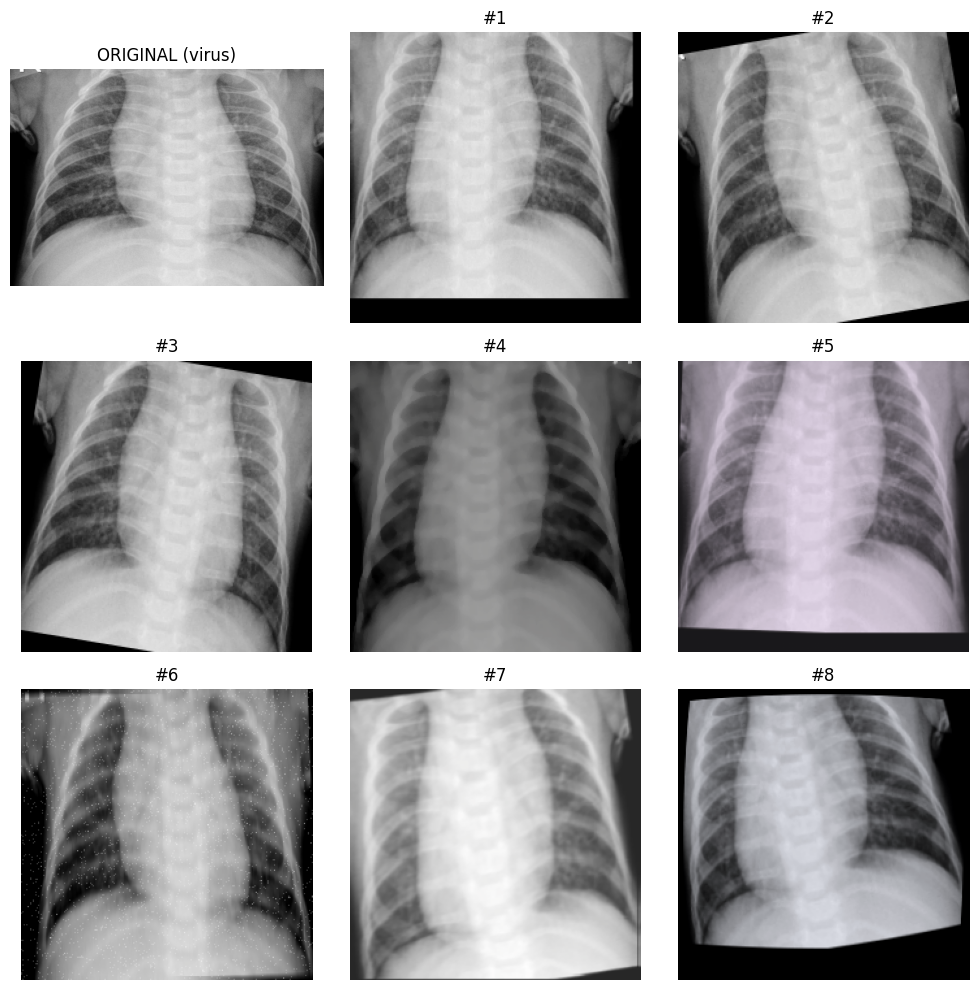

In [1]:
import gc, json, sys
from datetime import datetime
from pathlib import Path

import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score, precision_score,
                             recall_score, roc_auc_score)

ROOT = Path.cwd().resolve()
while not (ROOT / "cross_validation.py").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from ipynb.fs.full.preprocessing import get_data_pipeline

FINAL_DIR = ROOT / "results" / "svm" / "final_model"
EVAL_DIR = ROOT / "results" / "svm" / "evaluation"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

## 1. Chargement du pipeline final

Scaler + PCA + SVM rechargés depuis `svm_pipeline.joblib`.

In [2]:
with open(FINAL_DIR / "train_meta.json") as f:
    meta = json.load(f)
cfg = meta["config"]
print("Config du modèle final :")
print(json.dumps(cfg, indent=2))

bundle = joblib.load(FINAL_DIR / meta["pipeline_file"])
scaler, pca, svm = bundle["scaler"], bundle["pca"], bundle["svm"]
print(f"Pipeline chargé : {meta['pipeline_file']}")

Config du modèle final :
{
  "C": 10,
  "gamma": "scale",
  "kernel": "rbf",
  "pca_variance": 0.95
}
Pipeline chargé : svm_pipeline.joblib


## 2. Jeu de test final

On utilise exclusivement la vue test fournie par `preprocessing.ipynb` (resize + normalize, **pas** d'augmentation), puis on extrait les mêmes features que pour l'entraînement.

In [6]:
# Normalisation ImageNet appliquée par le pipeline : on l'inverse avant
# la conversion en niveaux de gris.
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
IMAGENET_STD = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)

def extract_features(dataset, batch_size=32, num_workers=0, desc="Extracting"):
    """Niveaux de gris aplatis (224*224=50176) + labels depuis un dataset.

    Le SVM opère sur des vecteurs plats : on dénormalise (ImageNet -> [0, 1]),
    on convertit en niveaux de gris (radiographies monochromes), on aplatit.
    """
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        num_workers=num_workers)
    feats, labels = [], []
    for batch in tqdm(loader, desc=desc):
        images = batch["image"].numpy()
        images = np.clip(images * IMAGENET_STD + IMAGENET_MEAN, 0, 1)
        gray = (0.2989 * images[:, 0] + 0.5870 * images[:, 1]
                + 0.1140 * images[:, 2])
        feats.append(gray.reshape(gray.shape[0], -1).astype(np.float32))
        labels.append(batch["label"].numpy())
    return np.concatenate(feats), np.concatenate(labels)

In [7]:
pipeline_data = get_data_pipeline()
test_view = pipeline_data["test_view"]
label_names = list(pipeline_data["label_names"].values())
print(f"Test set : {len(test_view)} images, classes = {label_names}")

X_test, y_test = extract_features(test_view, desc="Extraction test")
X_test_p = pca.transform(scaler.transform(X_test))
print(f"Features test : {X_test.shape} -> {X_test_p.shape}")

Test set : 624 images, classes = ['normal', 'bacteria', 'virus']























Extraction test: 100%|██████████| 20/20 [00:09<00:00,  2.16it/s]


Features test : (624, 50176) -> (624, 968)


## 3. Prédictions et métriques

Inférence sur l'ensemble du test set, puis calcul des métriques macro-averaged (équilibrage entre les 3 classes).

In [8]:
all_p = svm.predict(X_test_p)
all_probs = svm.predict_proba(X_test_p)
all_y = np.array(y_test)

metrics = {
    "accuracy": accuracy_score(all_y, all_p),
    "precision": precision_score(all_y, all_p, average="macro", zero_division=0),
    "recall": recall_score(all_y, all_p, average="macro", zero_division=0),
    "f1": f1_score(all_y, all_p, average="macro", zero_division=0),
}
try:
    metrics["roc_auc"] = roc_auc_score(all_y, all_probs, multi_class="ovr")
except ValueError:
    metrics["roc_auc"] = float("nan")

for k, v in metrics.items():
    print(f"{k:10s} {v:.4f}")

report = classification_report(all_y, all_p, target_names=label_names, output_dict=True)
print("\n" + classification_report(all_y, all_p, target_names=label_names))

accuracy   0.6795
precision  0.6924
recall     0.6713
f1         0.6536
roc_auc    0.8786

              precision    recall  f1-score   support

      normal       0.86      0.46      0.60       234
    bacteria       0.75      0.92      0.83       242
       virus       0.46      0.64      0.53       148

    accuracy                           0.68       624
   macro avg       0.69      0.67      0.65       624
weighted avg       0.73      0.68      0.67       624



## 4. Matrice de confusion

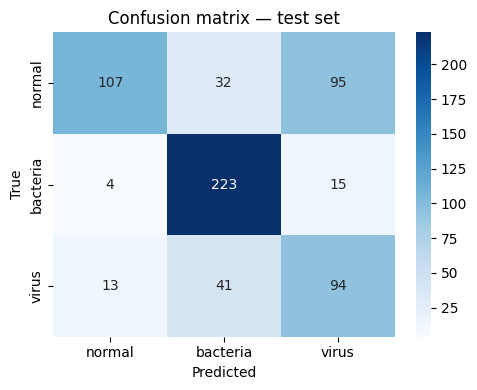

In [9]:
cm = confusion_matrix(all_y, all_p)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion matrix — test set")
plt.tight_layout()
plt.savefig(EVAL_DIR / "confusion_matrix.png", dpi=150)
plt.show()

## 5. Bar-chart des métriques globales

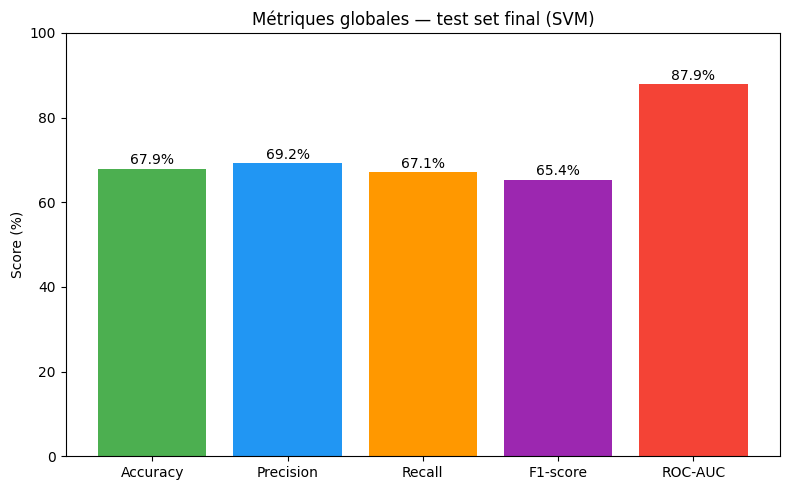

In [10]:
names = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
vals = [metrics["accuracy"], metrics["precision"], metrics["recall"],
        metrics["f1"], metrics["roc_auc"]]
pcts = [v * 100 for v in vals]
plt.figure(figsize=(8, 5))
plt.bar(names, pcts, color=["#4caf50", "#2196f3", "#ff9800", "#9c27b0", "#f44336"])
plt.ylabel("Score (%)"); plt.ylim(0, 100)
plt.title("Métriques globales — test set final (SVM)")
for i, v in enumerate(pcts):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.savefig(EVAL_DIR / "metrics_bar.png", dpi=150)
plt.show()

## 6. Exemples qualitatifs

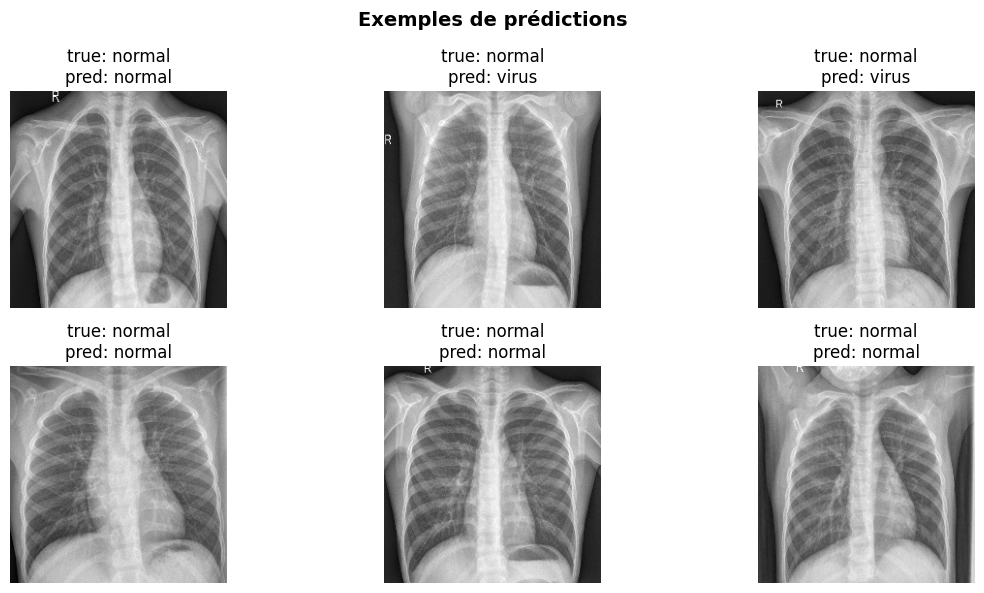

In [11]:
mean = np.array([0.485, 0.456, 0.406]); std = np.array([0.229, 0.224, 0.225])
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()
for i in range(6):
    img = test_view[i]["image"].numpy().transpose(1, 2, 0) * std + mean
    axes[i].imshow(np.clip(img, 0, 1)); axes[i].axis("off")
    axes[i].set_title(f"true: {label_names[all_y[i]]}\npred: {label_names[all_p[i]]}")
plt.suptitle("Exemples de prédictions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(EVAL_DIR / "predictions.png", dpi=150)
plt.show()

## 7. Sauvegarde des métriques

In [12]:
out = {
    "model": "SVM",
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "config": cfg,
    "test_size": int(len(test_view)),
    "metrics": metrics,
    "classification_report": report,
    "confusion_matrix": cm.tolist(),
}
with open(EVAL_DIR / "metrics.json", "w") as f:
    json.dump(out, f, indent=2)
print(f"Sauvegardé : {EVAL_DIR / 'metrics.json'}")

gc.collect()

Extraction test:   0%|          | 0/20 [01:29<?, ?it/s]

Sauvegardé : C:\Users\sh4rk\Documents\Zoidberg2.0\results\svm\evaluation\metrics.json


8777